--- CARGANDO DATASET ---
Total de registros cargados: 10000

=== ESTADÍSTICAS DESCRIPTIVAS REQUERIDAS ===
           dst_port    bytes_sent    bytes_recv  duration_sec       packets
count  10000.000000  1.000000e+04  1.000000e+04  10000.000000  1.000000e+04
mean    5272.963700  2.815289e+07  4.124360e+05    447.154662  1.605501e+04
std     7348.395782  3.115671e+08  1.964278e+06   4530.488171  1.672859e+05
min       21.000000  1.500000e+01  0.000000e+00      0.000000  1.000000e+00
25%       53.000000  5.544000e+03  1.328800e+04      8.507500  5.000000e+00
50%     3389.000000  2.233900e+04  5.529050e+04     21.435000  2.400000e+01
75%     8080.000000  9.478175e+04  2.213258e+05     44.145000  1.100000e+02
max    65460.000000  4.987050e+09  8.155783e+07  83028.150000  2.939448e+06


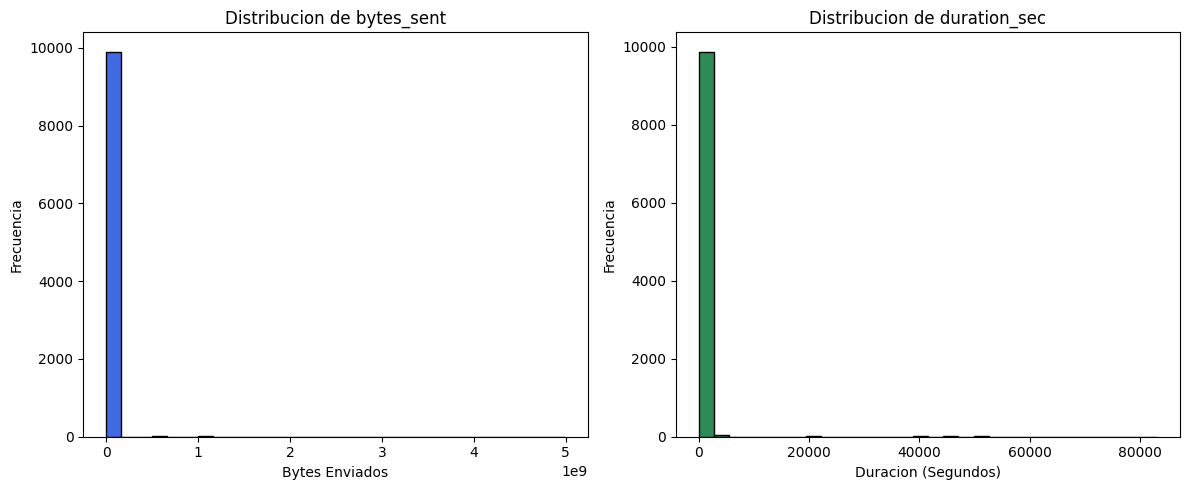


[OK] Preprocesamiento y Feature Engineering completados.

=== MÉTRICAS DE EVALUACIÓN (ANOMALÍAS) ===
Precision: 0.6360
Recall:    0.6360
F1-Score:  0.6360


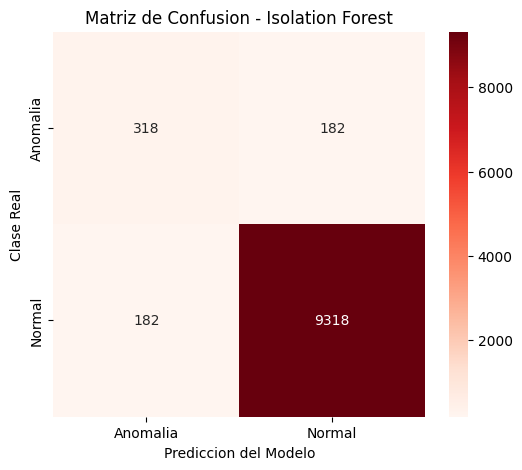

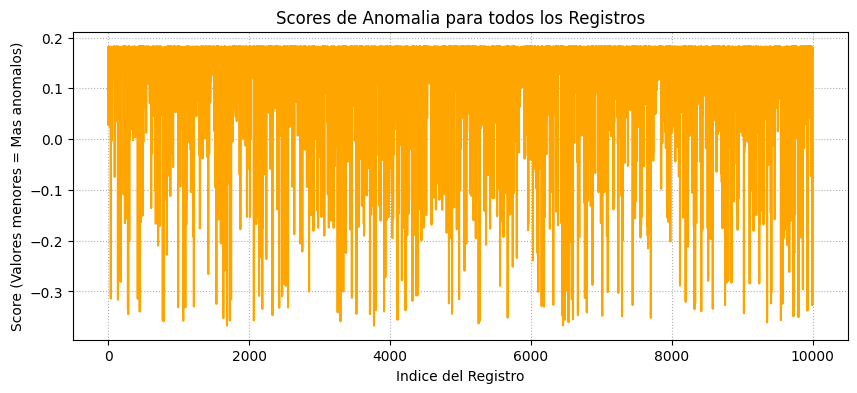


=== TOP 10 REGISTROS MÁS ANÓMALOS ===
          src_ip           dst_ip  dst_port protocol  bytes_sent  anomaly_score
1687  10.0.3.187   185.220.101.45       443      TCP  4706448909      -0.367585
3773  10.0.1.114   185.220.101.45      8080      TCP  4602183026      -0.367585
6456  10.0.1.254    38.168.189.92        80      UDP  4696305972      -0.367007
5258   10.0.2.73     205.91.80.48        80      TCP  4235188534      -0.362968
9352  10.0.3.174   185.220.101.45       443      TCP  4987050489      -0.361243
6533  10.0.0.237    23.129.64.214       443      TCP  4126191812      -0.360669
786   10.0.1.114    178.249.13.75        53      TCP  3385524170      -0.358949
3297  10.0.1.238  178.172.125.218       443      TCP  4892277928      -0.358949
5277   10.0.1.54  188.205.159.113       443      TCP  4402262853      -0.358376
1066   10.0.2.73   185.220.101.45      8080      TCP  4313654623      -0.357804

[OK] Archivos 'modelo_anomalias.pkl' y 'scaler_anomalias.pkl' generados.


In [ ]:
# ==============================================================================
# LABORATORIO 3: MODELO DE DETECCIÓN DE ANOMALÍAS CON ML (UPeU)
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import joblib

# 1. Cargar el dataset que subiste a la barra lateral
print("--- CARGANDO DATASET ---")
df = pd.read_csv('network_traffic.csv')
print(f"Total de registros cargados: {len(df)}")

# --- TAREA 3.1: EXPLORACIÓN Y PREPROCESAMIENTO ---
print("\n=== ESTADÍSTICAS DESCRIPTIVAS REQUERIDAS ===")
print(df.describe())

# Tratar valores nulos si existieran
df = df.dropna()

# Visualizar la distribución de bytes_sent y duration_sec con histogramas (Requisito 2)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(df['bytes_sent'], bins=30, color='royalblue', edgecolor='black')
plt.title('Distribucion de bytes_sent')
plt.xlabel('Bytes Enviados')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
plt.hist(df['duration_sec'], bins=30, color='seagreen', edgecolor='black')
plt.title('Distribucion de duration_sec')
plt.xlabel('Duracion (Segundos)')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

# Feature Engineering: crear al menos 2 nuevas variables derivadas (Requisito 4)
df['ratio_bytes'] = df['bytes_sent'] / (df['bytes_recv'] + 1)
df['bytes_por_segundo'] = (df['bytes_sent'] + df['bytes_recv']) / (df['duration_sec'] + 0.1)

# Normalizar las features numéricas con StandardScaler (Requisito 5)
features = ['bytes_sent', 'bytes_recv', 'duration_sec', 'packets', 'ratio_bytes', 'bytes_por_segundo']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])
print("\n[OK] Preprocesamiento y Feature Engineering completados.")

# --- TAREA 3.2: ENTRENAMIENTO DEL MODELO ---
# Entrenar Isolation Forest (excluyendo la columna label real) con los parámetros sugeridos
model = IsolationForest(contamination=0.05, n_estimators=100, random_state=42)
model.fit(X_scaled)

# Obtener predicciones (-1 = anomalía, 1 = normal)
df['pred'] = model.predict(X_scaled)

# Convertir la columna real 'label' para poder evaluar (normal -> 1, anomaly -> -1)
df['label_numeric'] = df['label'].map({'normal': 1, 'anomaly': -1})

# Calcule las métricas de evaluación usando la columna label
precision = precision_score(df['label_numeric'], df['pred'], pos_label=-1)
recall = recall_score(df['label_numeric'], df['pred'], pos_label=-1)
f1 = f1_score(df['label_numeric'], df['pred'], pos_label=-1)

print(f"\n=== MÉTRICAS DE EVALUACIÓN (ANOMALÍAS) ===")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

# Grafique la matriz de confusión con seaborn
cm = confusion_matrix(df['label_numeric'], df['pred'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Anomalia', 'Normal'], yticklabels=['Anomalia', 'Normal'])
plt.title('Matriz de Confusion - Isolation Forest')
plt.ylabel('Clase Real')
plt.xlabel('Prediccion del Modelo')
plt.show()

# --- TAREA 3.3: INTERPRETACIÓN Y UMBRAL ---
df['anomaly_score'] = model.decision_function(X_scaled)

# Graficar el score de anomalía para todos los registros
plt.figure(figsize=(10, 4))
plt.plot(df['anomaly_score'].values, color='orange')
plt.title('Scores de Anomalia para todos los Registros')
plt.xlabel('Indice del Registro')
plt.ylabel('Score (Valores menores = Mas anomalos)')
plt.grid(True, linestyle=':')
plt.show()

# Liste los Top 10 registros más anómalos
top_10 = df.sort_values(by='anomaly_score').head(10)
print("\n=== TOP 10 REGISTROS MÁS ANÓMALOS ===")
print(top_10[['src_ip', 'dst_ip', 'dst_port', 'protocol', 'bytes_sent', 'anomaly_score']].to_string())

# --- TAREA 3.4: EXPORTACIÓN DEL MODELO ---
# Serializar el modelo entrenado y el escalador con joblib
joblib.dump(model, 'modelo_anomalias.pkl')
joblib.dump(scaler, 'scaler_anomalias.pkl')
print("\n[OK] Archivos 'modelo_anomalias.pkl' y 'scaler_anomalias.pkl' generados.")